# IMPORTAÇÕES DE BIBLIOTECAS E CONFIGURAÇÕES VISUAIS


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, roc_auc_score

In [2]:
# Armazenar e ler o dataframe
dados = pd.read_csv('/content/df_telecom_processado.csv')
dados.head()

,id_cliente,evasao,genero,cidadao_senior,possui_parceiro,possui_dependentes,meses_contrato,servico_telefone,multiplas_linhas,tipo_servico_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_online,metodo_pagamento,cobranca_mensal,cobranca_total,Contas_Diarias
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,1,Não,DSL,...,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.6,593.30,2.186667
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,1,Sim,DSL,...,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.9,542.40,1.996667
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,1,Não,Fibra óptica,...,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.9,280.85,2.463333
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,1,Não,Fibra óptica,...,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.0,1237.85,3.266667
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,1,Não,Fibra óptica,...,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.9,267.40,2.796667


#TRATAMENTO DE DADOS

In [3]:
dados = dados.drop(columns=['id_cliente'], axis=1)

In [4]:
# Tratar coluna genero
dados['genero'] = dados['genero'].replace({'Feminino':0, 'Masculino':1})
dados.head()

/tmp/ipykernel_340/4145245344.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dados['genero'] = dados['genero'].replace({'Feminino':0, 'Masculino':1})


,evasao,genero,cidadao_senior,possui_parceiro,possui_dependentes,meses_contrato,servico_telefone,multiplas_linhas,tipo_servico_internet,seguranca_online,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_online,metodo_pagamento,cobranca_mensal,cobranca_total,Contas_Diarias
0,Não,0,0,Sim,Sim,9,1,Não,DSL,0,...,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.6,593.30,2.186667
1,Não,1,0,Não,Não,9,1,Sim,DSL,0,...,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.9,542.40,1.996667
2,Sim,1,0,Não,Não,4,1,Não,Fibra óptica,0,...,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.9,280.85,2.463333
3,Sim,1,1,Sim,Não,13,1,Não,Fibra óptica,0,...,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.0,1237.85,3.266667
4,Sim,0,1,Sim,Não,3,1,Não,Fibra óptica,0,...,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.9,267.40,2.796667


In [5]:

print(dados.apply(pd.Series.unique))

evasao                                                          [Não, Sim]
genero                                                              [0, 1]
cidadao_senior                                                      [0, 1]
possui_parceiro                                                 [Sim, Não]
possui_dependentes                                              [Sim, Não]
meses_contrato           [9, 4, 13, 3, 71, 63, 7, 65, 54, 72, 5, 56, 34...
servico_telefone                                                    [1, 0]
multiplas_linhas                       [Não, Sim, Sem serviço de telefone]
tipo_servico_internet                             [DSL, Fibra óptica, Não]
seguranca_online                                                    [0, 1]
backup_online                                                       [1, 0]
protecao_dispositivo                   [Não, Sim, Sem serviço de internet]
suporte_tecnico                        [Sim, Não, Sem serviço de internet]
streaming_tv             

In [6]:
lista = list(dados.columns)
colunas_categoricas = lista[7:18]
print(colunas_categoricas)
pd.get_dummies(dados, columns=colunas_categoricas)

['multiplas_linhas', 'tipo_servico_internet', 'seguranca_online', 'backup_online', 'protecao_dispositivo', 'suporte_tecnico', 'streaming_tv', 'streaming_filmes', 'tipo_contrato', 'fatura_online', 'metodo_pagamento']


,evasao,genero,cidadao_senior,possui_parceiro,possui_dependentes,meses_contrato,servico_telefone,cobranca_mensal,cobranca_total,Contas_Diarias,...,streaming_filmes_Sim,tipo_contrato_Anual,tipo_contrato_Dois anos,tipo_contrato_Mensal,fatura_online_Não,fatura_online_Sim,metodo_pagamento_Cartão de crédito (automático),metodo_pagamento_Cheque eletrônico,metodo_pagamento_Cheque enviado,metodo_pagamento_Transferência bancária (automática)
0,Não,0,0,Sim,Sim,9,1,65.60,593.30,2.186667,...,False,True,False,False,False,True,False,False,True,False
1,Não,1,0,Não,Não,9,1,59.90,542.40,1.996667,...,True,False,False,True,True,False,False,False,True,False
2,Sim,1,0,Não,Não,4,1,73.90,280.85,2.463333,...,False,False,False,True,False,True,False,True,False,False
3,Sim,1,1,Sim,Não,13,1,98.00,1237.85,3.266667,...,True,False,False,True,False,True,False,True,False,False
4,Sim,0,1,Sim,Não,3,1,83.90,267.40,2.796667,...,False,False,False,True,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,Não,0,0,Não,Não,13,1,55.15,742.90,1.838333,...,False,True,False,False,True,False,False,False,True,False
7028,Sim,1,0,Sim,Não,22,1,85.10,1873.70,2.836667,...,True,False,False,True,False,True,False,True,False,False
7029,Não,1,0,Não,Não,2,1,50.30,92.75,1.676667,...,False,False,False,True,False,True,False,False,True,False
7030,Não,1,0,Sim,Sim,67,1,67.85,4627.65,2.261667,...,True,False,True,False,True,False,False,False,True,False


In [7]:
# Transformando variáveis categóricas para numéricas
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

one_hot_enc = make_column_transformer(
    (OneHotEncoder(handle_unknown = 'ignore'),
    colunas_categoricas),
    remainder='passthrough')
dados = one_hot_enc.fit_transform(dados)
dados = pd.DataFrame(dados, columns=one_hot_enc.get_feature_names_out())
dados

,onehotencoder__multiplas_linhas_Não,onehotencoder__multiplas_linhas_Sem serviço de telefone,onehotencoder__multiplas_linhas_Sim,onehotencoder__tipo_servico_internet_DSL,onehotencoder__tipo_servico_internet_Fibra óptica,onehotencoder__tipo_servico_internet_Não,onehotencoder__seguranca_online_0,onehotencoder__seguranca_online_1,onehotencoder__backup_online_0,onehotencoder__backup_online_1,...,remainder__evasao,remainder__genero,remainder__cidadao_senior,remainder__possui_parceiro,remainder__possui_dependentes,remainder__meses_contrato,remainder__servico_telefone,remainder__cobranca_mensal,remainder__cobranca_total,remainder__Contas_Diarias
0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,Não,0,0,Sim,Sim,9,1,65.6,593.3,2.186667
1,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,Não,1,0,Não,Não,9,1,59.9,542.4,1.996667
2,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,Sim,1,0,Não,Não,4,1,73.9,280.85,2.463333
3,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Sim,1,1,Sim,Não,13,1,98.0,1237.85,3.266667
4,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,Sim,0,1,Sim,Não,3,1,83.9,267.4,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,Não,0,0,Não,Não,13,1,55.15,742.9,1.838333
7028,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,Sim,1,0,Sim,Não,22,1,85.1,1873.7,2.836667
7029,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,Não,1,0,Não,Não,2,1,50.3,92.75,1.676667
7030,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,Não,1,0,Sim,Sim,67,1,67.85,4627.65,2.261667


# VERIFICAÇÃO DA PROPORÇÃO DE EVASÃO

In [8]:
dados.value_counts('remainder__evasao')

,count
remainder__evasao,
Não,5163
Sim,1869


# MATRIZ DE CORRELAÇÃO

In [9]:
# verifica correlação com a variável de evasão
# Converter 'remainder__evasao' e outras colunas binárias para numérico
dados['remainder__evasao'] = dados['remainder__evasao'].replace({'Não': 0, 'Sim': 1})
dados['remainder__possui_parceiro'] = dados['remainder__possui_parceiro'].replace({'Não': 0, 'Sim': 1})
dados['remainder__possui_dependentes'] = dados['remainder__possui_dependentes'].replace({'Não': 0, 'Sim': 1})

corr = dados.corr()['remainder__evasao']
corr

/tmp/ipykernel_340/276182357.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dados['remainder__evasao'] = dados['remainder__evasao'].replace({'Não': 0, 'Sim': 1})
/tmp/ipykernel_340/276182357.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dados['remainder__possui_parceiro'] = dados['remainder__possui_parceiro'].replace({'Não': 0, 'Sim': 1})
/tmp/ipykernel_340/276182357.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `

,remainder__evasao
onehotencoder__multiplas_linhas_Não,-0.032654
onehotencoder__multiplas_linhas_Sem serviço de telefone,-0.011691
onehotencoder__multiplas_linhas_Sim,0.040033
onehotencoder__tipo_servico_internet_DSL,-0.124141
onehotencoder__tipo_servico_internet_Fibra óptica,0.307463
onehotencoder__tipo_servico_internet_Não,-0.227578
onehotencoder__seguranca_online_0,0.171270
onehotencoder__seguranca_online_1,-0.171270
onehotencoder__backup_online_0,0.082307
onehotencoder__backup_online_1,-0.082307


In [10]:
# Correlação maior que 3
corr[corr > 0.3]

,remainder__evasao
onehotencoder__tipo_servico_internet_Fibra óptica,0.307463
onehotencoder__suporte_tecnico_Não,0.336877
onehotencoder__tipo_contrato_Mensal,0.404565
onehotencoder__metodo_pagamento_Cheque eletrônico,0.301455
remainder__evasao,1.000000


In [11]:
# Correlação menor que -0.3
corr[corr < -0.3]

,remainder__evasao
onehotencoder__tipo_contrato_Dois anos,-0.301552
remainder__meses_contrato,-0.354049


# RELAÇÃO ENTRE VARIÁVEIS IMPORTANTES E EVASÃO

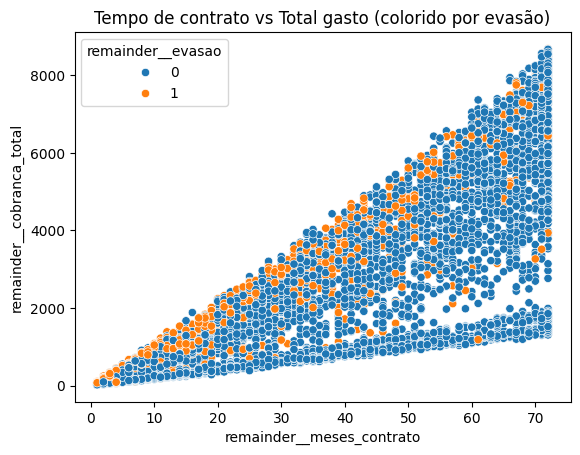

In [12]:
# Tempo de contrato vs Total gasto, colorindo por Churn
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='remainder__meses_contrato', y='remainder__cobranca_total', hue='remainder__evasao', data=dados)
plt.title("Tempo de contrato vs Total gasto (colorido por evasão)")
plt.show()

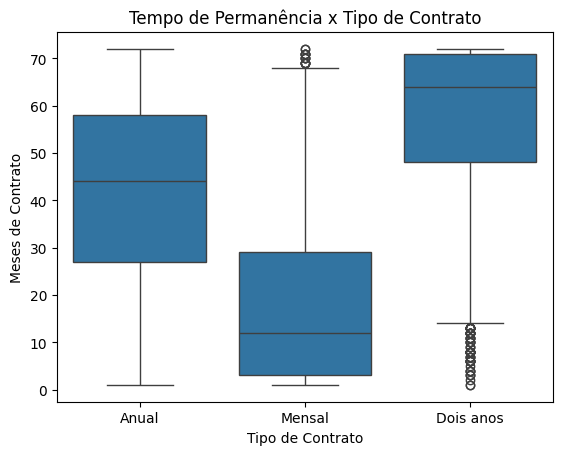

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reconstruct 'tipo_contrato' from one-hot encoded columns for plotting
contract_type_cols = [
    'onehotencoder__tipo_contrato_Anual',
    'onehotencoder__tipo_contrato_Dois anos',
    'onehotencoder__tipo_contrato_Mensal'
]

def get_contract_type(row):
    if row['onehotencoder__tipo_contrato_Anual'] == 1.0:
        return 'Anual'
    elif row['onehotencoder__tipo_contrato_Dois anos'] == 1.0:
        return 'Dois anos'
    elif row['onehotencoder__tipo_contrato_Mensal'] == 1.0:
        return 'Mensal'
    return 'Outro'

dados['reconstructed_tipo_contrato'] = dados.apply(get_contract_type, axis=1)

sns.boxplot(x='reconstructed_tipo_contrato',
               y='remainder__meses_contrato',
               data=dados)

plt.title("Tempo de Permanência x Tipo de Contrato")
plt.xlabel("Tipo de Contrato")
plt.ylabel("Meses de Contrato")
plt.show()

Observa-se que clientes com menor tempo de contrato apresentam maior índice de evasão. Isso indica que os primeiros meses são decisivos para a retenção do cliente.

# REMOÇÃO DE COLUNAS IRRELEVANTES

In [14]:

dados.columns

Index(['onehotencoder__multiplas_linhas_Não',
       'onehotencoder__multiplas_linhas_Sem serviço de telefone',
       'onehotencoder__multiplas_linhas_Sim',
       'onehotencoder__tipo_servico_internet_DSL',
       'onehotencoder__tipo_servico_internet_Fibra óptica',
       'onehotencoder__tipo_servico_internet_Não',
       'onehotencoder__seguranca_online_0',
       'onehotencoder__seguranca_online_1', 'onehotencoder__backup_online_0',
       'onehotencoder__backup_online_1',
       'onehotencoder__protecao_dispositivo_Não',
       'onehotencoder__protecao_dispositivo_Sem serviço de internet',
       'onehotencoder__protecao_dispositivo_Sim',
       'onehotencoder__suporte_tecnico_Não',
       'onehotencoder__suporte_tecnico_Sem serviço de internet',
       'onehotencoder__suporte_tecnico_Sim', 'onehotencoder__streaming_tv_Não',
       'onehotencoder__streaming_tv_Sem serviço de internet',
       'onehotencoder__streaming_tv_Sim',
       'onehotencoder__streaming_filmes_Não',
       

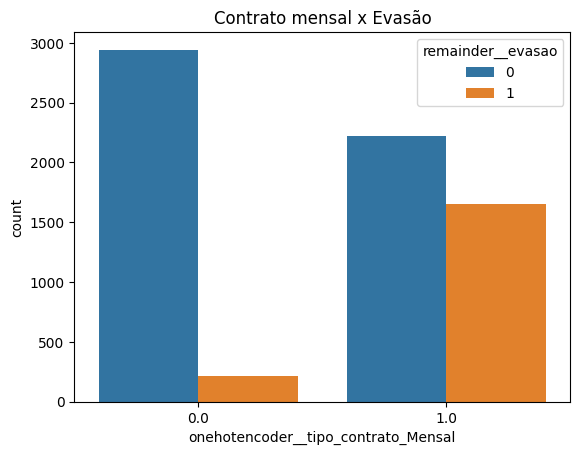

In [15]:

sns.countplot(x='onehotencoder__tipo_contrato_Mensal', hue='remainder__evasao', data=dados)
plt.title("Contrato mensal x Evasão")
plt.show()

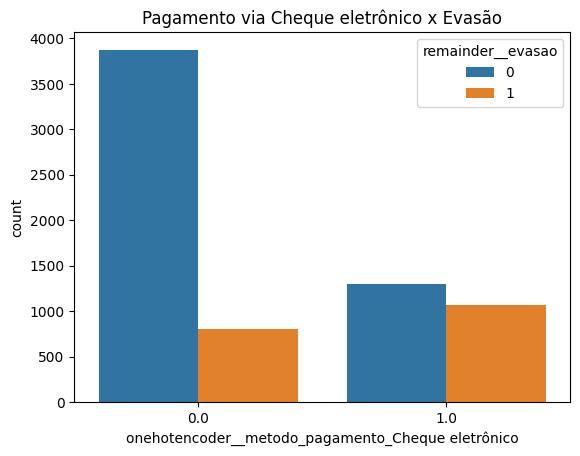

In [16]:
sns.countplot(x='onehotencoder__metodo_pagamento_Cheque eletrônico', hue='remainder__evasao', data=dados)
plt.title("Pagamento via Cheque eletrônico x Evasão")
plt.show()

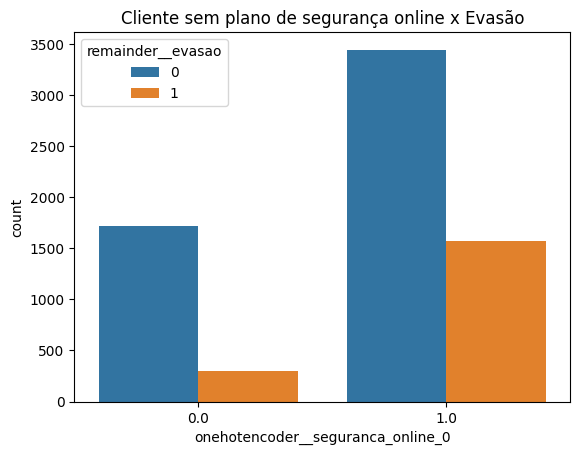

In [17]:
sns.countplot(x='onehotencoder__seguranca_online_0', hue='remainder__evasao', data=dados)
plt.title("Cliente sem plano de segurança online x Evasão")
plt.show()

# ENCODING DAS VARIÁVEIS CATEGÓRICAS

In [18]:
# Definindo variável dependente e explicativas
# X = dados.drop(columns='remainder__evasao')
# y = dados['remainder__evasao']
# Moved to cell TC-aNJMBxiAt to resolve NameError

# SEPARAÇÃO TREINO E TESTE

In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Definindo variável dependente e explicativas
# Excluir a coluna 'reconstructed_tipo_contrato' pois é uma string e não deve ser usada diretamente no modelo numérico
X = dados.drop(columns=['remainder__evasao', 'reconstructed_tipo_contrato'])
y = dados['remainder__evasao']

# Separar os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modelo base - DummyClassifier
model_dummy = DummyClassifier()
model_dummy.fit(X_train, y_train)

acuracia_dummy = model_dummy.score(X_test, y_test)
print(f'Acurácia do modelo DummyClassifier: {acuracia_dummy:.2%}')

Acurácia do modelo DummyClassifier: 73.65%


In [20]:
# Modelo KNN - KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)

acuracia_knn = model_knn.score(X_test, y_test)
print(f'Acurácia do modelo KNeighborsClassifier: {acuracia_knn:.2%}')

Acurácia do modelo KNeighborsClassifier: 76.21%


# NORMALIZAÇÃO (PARA REGRESSÃO LOGÍSTICA)

In [21]:
# Modelo Regressão Logística precisa normalizar dados
# Normaliza dados
from sklearn.preprocessing import StandardScaler

normaliza = StandardScaler()
X_train_normalizado = normaliza.fit_transform(X_train)
X_test_normalizado = normaliza.transform(X_test)

# Treina o modelo com os dados normalizados
# Modelo Regressão
from sklearn.linear_model import LogisticRegression

model_logreg = LogisticRegression(max_iter=1000)
model_logreg.fit(X_train_normalizado, y_train)

acuracia_logreg = model_logreg.score(X_test_normalizado, y_test)
print(f'Acurácia do modelo LogisticRegression: {acuracia_logreg:.2%}')


Acurácia do modelo LogisticRegression: 80.28%


# MODELO RANDOM FOREST (SEM NORMALIZAÇÃO)

In [22]:
# Modelo RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

model_rfc = RandomForestClassifier()
model_rfc.fit(X_train, y_train)

acuracia_rfc = model_rfc.score(X_test, y_test)
print(f'Acurácia do modelo RandomForestClassifier: {acuracia_rfc:.2%}')

Acurácia do modelo RandomForestClassifier: 79.05%


In [24]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

model_tree = DecisionTreeClassifier(
    max_depth=4,              # limita profundidade
    min_samples_leaf=20,      # evita folhas muito pequenas
    random_state=42
)

model_tree.fit(X_train, y_train)

acuracia_treino = model_tree.score(X_train, y_train)
acuracia_teste = model_tree.score(X_test, y_test)

print(f'Acurácia TREINO: {acuracia_treino:.2%}')
print(f'Acurácia TESTE: {acuracia_teste:.2%}')

Acurácia TREINO: 79.93%
Acurácia TESTE: 78.58%


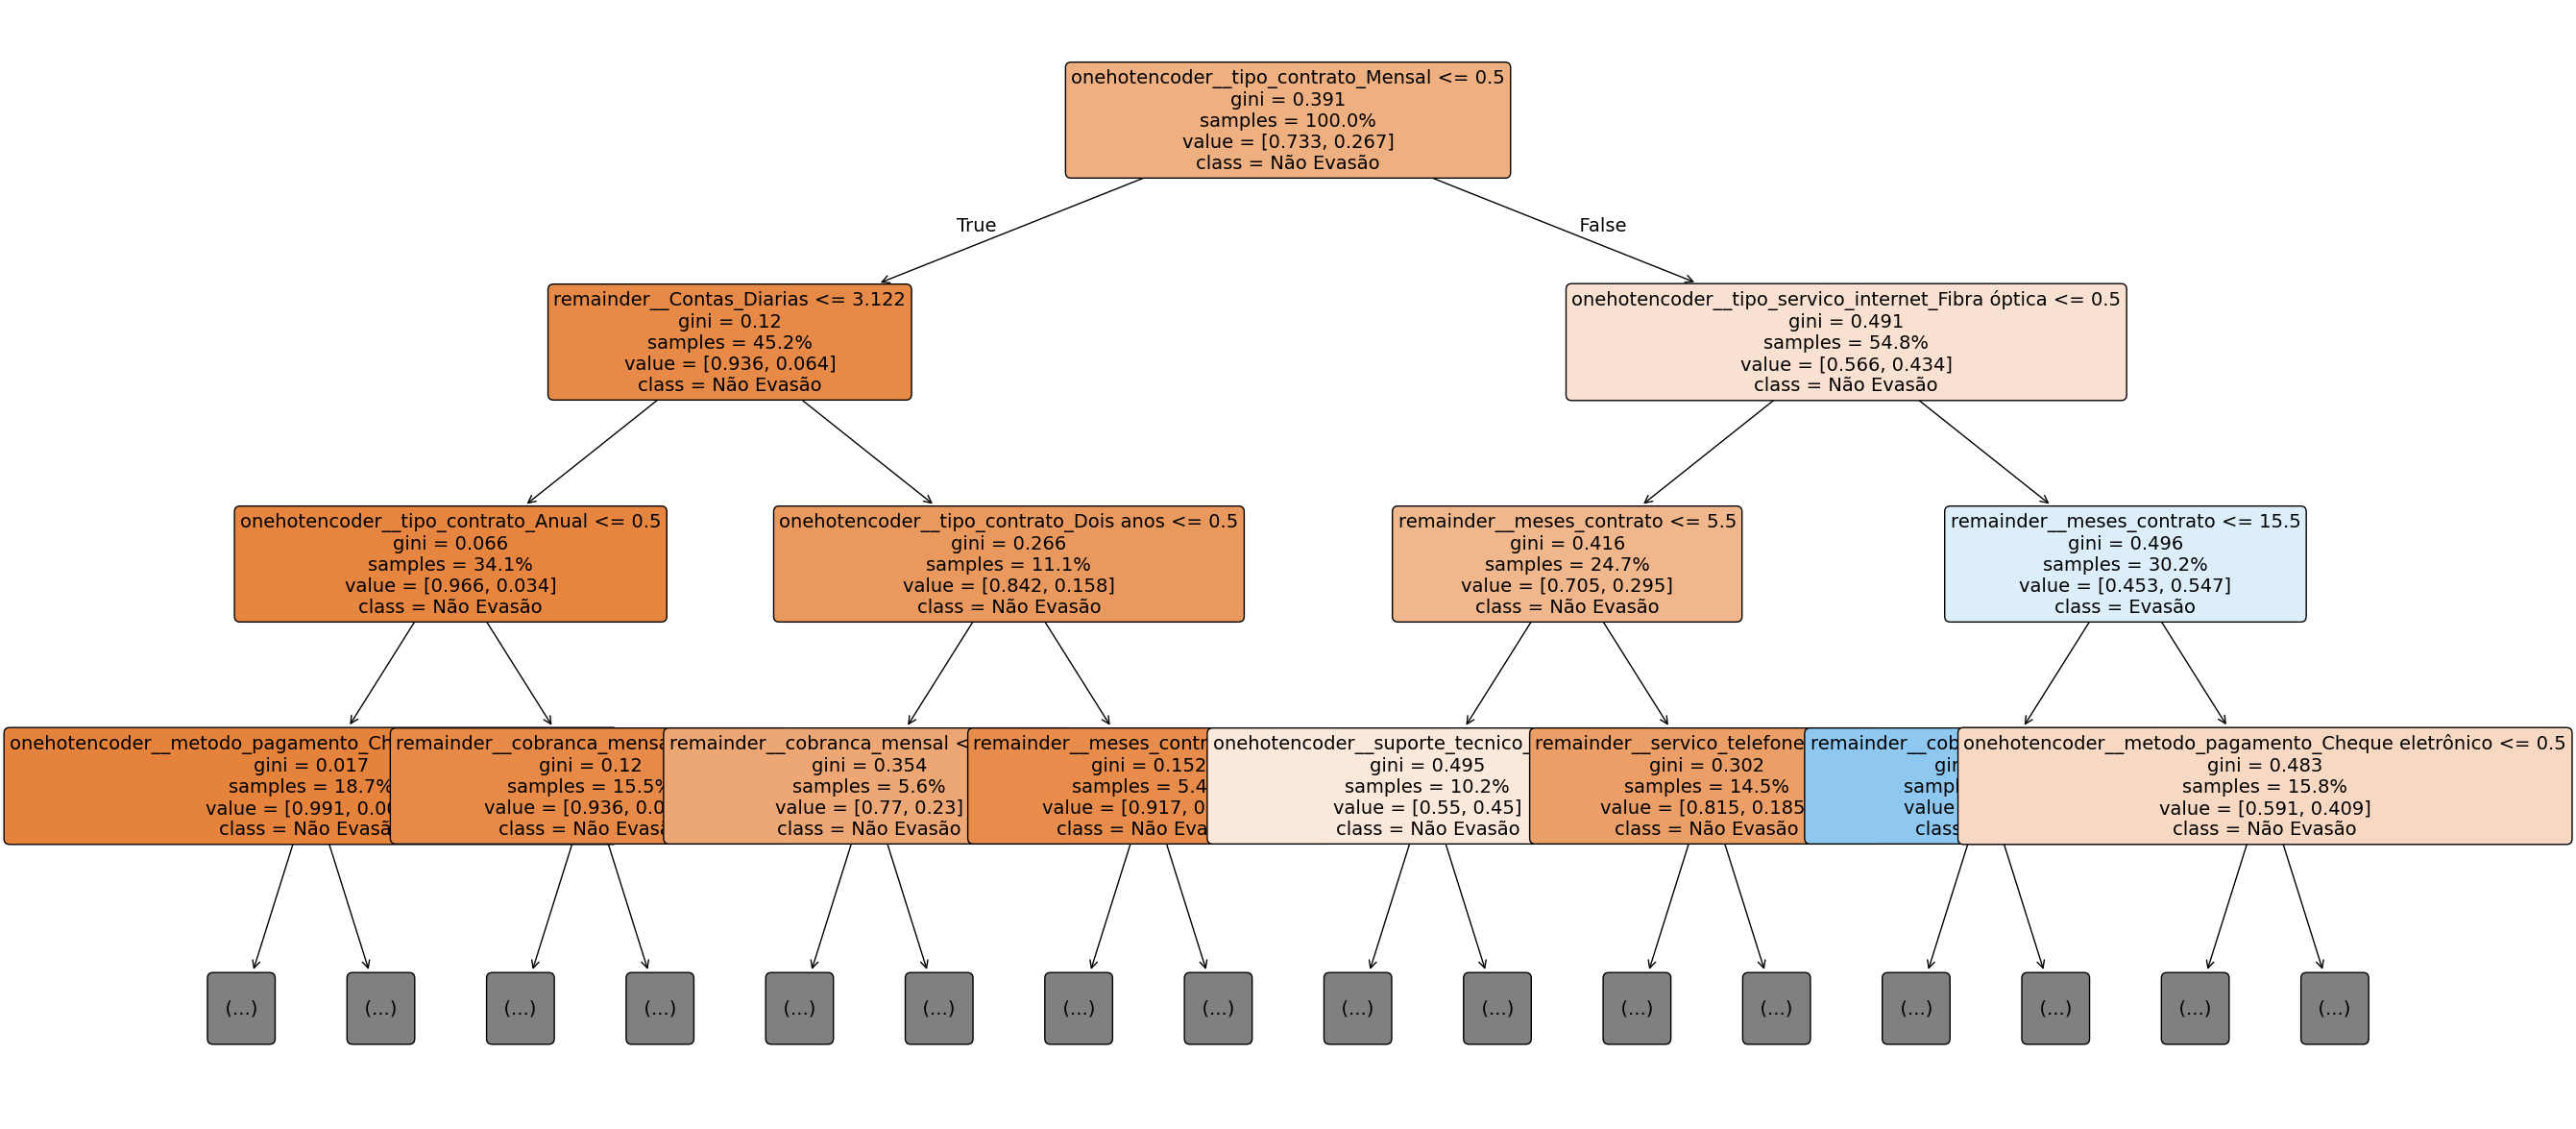

In [25]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(30,15))  # aumenta bastante o tamanho da figura

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=['Não Evasão', 'Evasão'],
    filled=True,
    proportion=True,
    rounded=True,
    max_depth=3,
    fontsize=14  # aumenta o tamanho da fonte
)

plt.show()

O modelo de árvore de decisão segmenta os clientes a partir das variáveis mais importantes para prever a evasão. Cada divisão representa uma regra baseada nos dados, facilitando a interpretação dos principais critérios que levam ao cancelamento.

# IMPORTÂNCIA DAS VARIÁVEIS (Random Forest)

In [26]:
# Modelo RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

model_rfc = RandomForestClassifier()
model_rfc.fit(X_train, y_train)

acuracia_rfc = model_rfc.score(X_test, y_test)
print(f'Acurácia do modelo RandomForestClassifier: {acuracia_rfc:.2%}')


Acurácia do modelo RandomForestClassifier: 77.96%


# ANÁLISE DE OVERFITTING

In [27]:
'''
  Avaliar:
    Acurácia
    Precisão
    Recall
    F1-score
    Matriz de confusão
'''
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

Acurácia: 73.65%
Precisão: 0.00%
Recall: 0.00%
F1-score: 0.00%
Erro UndefinedMetricWarning aparece pois o modelo previu somente um valor
      então algumas métricas ficam indefinidas.
Matriz de confusão:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


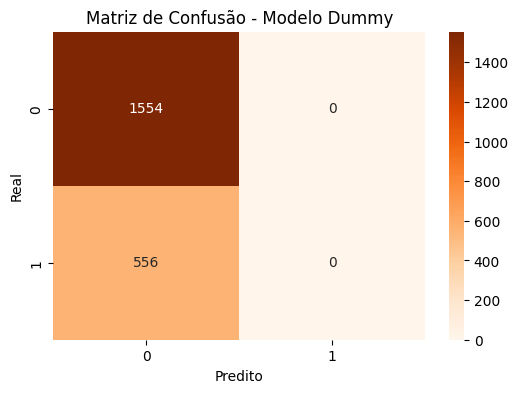

In [28]:
# Avaliar modelo base - DummyClassifier
y_pred_dummy = (model_dummy.predict(X_test))

print(f'Acurácia: {accuracy_score(y_test, y_pred_dummy):.2%}')
print(f'Precisão: {precision_score(y_test, y_pred_dummy):.2%}')
print(f'Recall: {recall_score(y_test, y_pred_dummy):.2%}')
print(f'F1-score: {f1_score(y_test, y_pred_dummy):.2%}')
print('''Erro UndefinedMetricWarning aparece pois o modelo previu somente um valor
      então algumas métricas ficam indefinidas.''')
print('Matriz de confusão:')

cm = confusion_matrix(y_test, y_pred_dummy)

# Plot com seaborn
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Modelo Dummy")

plt.show()

Acurácia: 76.21%
Precisão: 55.77%
Recall: 46.94%
F1-score: 50.98%
Matriz de confusão:


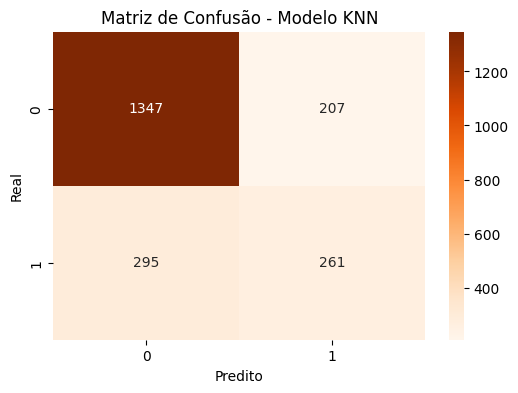

In [29]:
# Avaliar modelo KNeighborsClassifier
y_pred_knn = model_knn.predict(X_test)

print(f'Acurácia: {accuracy_score(y_test, y_pred_knn):.2%}')
print(f'Precisão: {precision_score(y_test, y_pred_knn):.2%}')
print(f'Recall: {recall_score(y_test, y_pred_knn):.2%}')
print(f'F1-score: {f1_score(y_test, y_pred_knn):.2%}')

print('Matriz de confusão:')

cm = confusion_matrix(y_test, y_pred_knn)

# Plot com seaborn
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Modelo KNN")

plt.show()

Acurácia: 80.28%
Precisão: 64.17%
Recall: 57.01%
F1-score: 60.38%
Matriz de confusão:


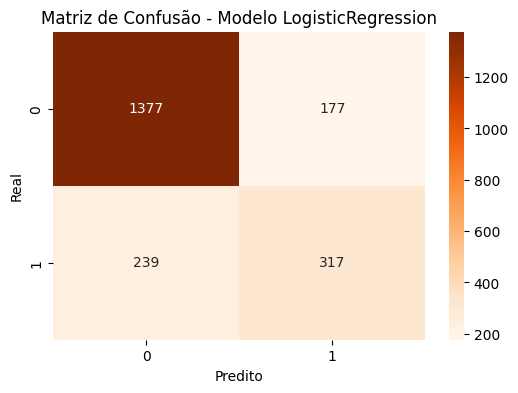

In [30]:
# Avaliar modelo LogisticRegression
# Probabilidades previstas
y_probs = model_logreg.predict_proba(X_test_normalizado)[:, 1]

# Ajustando o threshold
threshold = 0.3  # exemplo: mais baixo para aumentar recall
y_pred_logreg = (y_probs >= threshold).astype(int)

y_pred_logreg = model_logreg.predict(X_test_normalizado)

print(f'Acurácia: {accuracy_score(y_test, y_pred_logreg):.2%}')
print(f'Precisão: {precision_score(y_test, y_pred_logreg):.2%}')
print(f'Recall: {recall_score(y_test, y_pred_logreg):.2%}')
print(f'F1-score: {f1_score(y_test, y_pred_logreg):.2%}')

print('Matriz de confusão:')

cm = confusion_matrix(y_test, y_pred_logreg)

# Plot com seaborn
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Modelo LogisticRegression")

plt.show()

Acurácia: 78.58%
Precisão: 61.50%
Recall: 50.00%
F1-score: 55.16%
Matriz de confusão:


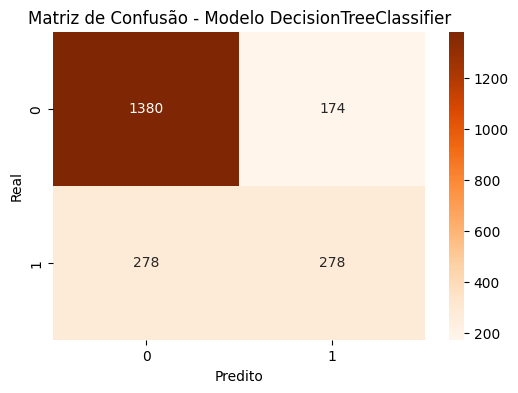

In [31]:
# Avaliar modelo DecisionTreeClassifier
y_pred_tree = model_tree.predict(X_test)

print(f'Acurácia: {accuracy_score(y_test, y_pred_tree):.2%}')
print(f'Precisão: {precision_score(y_test, y_pred_tree):.2%}')
print(f'Recall: {recall_score(y_test, y_pred_tree):.2%}')
print(f'F1-score: {f1_score(y_test, y_pred_tree):.2%}')

print('Matriz de confusão:')

cm = confusion_matrix(y_test, y_pred_tree)

# Plot com seaborn
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Modelo DecisionTreeClassifier")

plt.show()

Acurácia: 77.96%
Precisão: 59.78%
Recall: 50.00%
F1-score: 54.46%
Matriz de confusão:


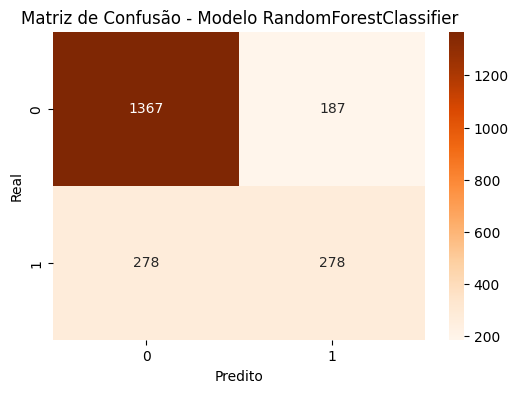

In [32]:
# Avaliar modelo RandomForestClassifier
y_pred_rfc = model_rfc.predict(X_test)

print(f'Acurácia: {accuracy_score(y_test, y_pred_rfc):.2%}')
print(f'Precisão: {precision_score(y_test, y_pred_rfc):.2%}')
print(f'Recall: {recall_score(y_test, y_pred_rfc):.2%}')
print(f'F1-score: {f1_score(y_test, y_pred_rfc):.2%}')

print('Matriz de confusão:')

cm = confusion_matrix(y_test, y_pred_rfc)

# Plot com seaborn
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Modelo RandomForestClassifier")

plt.show()

In [33]:
import pandas as pd

# Definir as métricas de desempenho para cada modelo
dese_dummy = {
    'Modelo': 'Dummy',
    'Acurácia': accuracy_score(y_test, y_pred_dummy),
    'Precisão': precision_score(y_test, y_pred_dummy, zero_division=0),
    'Recall': recall_score(y_test, y_pred_dummy, zero_division=0),
    'F1-score': f1_score(y_test, y_pred_dummy, zero_division=0)
}

dese_knn = {
    'Modelo': 'KNN',
    'Acurácia': accuracy_score(y_test, y_pred_knn),
    'Precisão': precision_score(y_test, y_pred_knn, zero_division=0),
    'Recall': recall_score(y_test, y_pred_knn, zero_division=0),
    'F1-score': f1_score(y_test, y_pred_knn, zero_division=0)
}

dese_logreg = {
    'Modelo': 'Regressão Logística',
    'Acurácia': accuracy_score(y_test, y_pred_logreg),
    'Precisão': precision_score(y_test, y_pred_logreg, zero_division=0),
    'Recall': recall_score(y_test, y_pred_logreg, zero_division=0),
    'F1-score': f1_score(y_test, y_pred_logreg, zero_division=0)
}

dese_tree = {
    'Modelo': 'Árvore de Decisão',
    'Acurácia': accuracy_score(y_test, y_pred_tree),
    'Precisão': precision_score(y_test, y_pred_tree, zero_division=0),
    'Recall': recall_score(y_test, y_pred_tree, zero_division=0),
    'F1-score': f1_score(y_test, y_pred_tree, zero_division=0)
}

dese_rfc = {
    'Modelo': 'Random Forest',
    'Acurácia': accuracy_score(y_test, y_pred_rfc),
    'Precisão': precision_score(y_test, y_pred_rfc, zero_division=0),
    'Recall': recall_score(y_test, y_pred_rfc, zero_division=0),
    'F1-score': f1_score(y_test, y_pred_rfc, zero_division=0)
}

# Criar o DataFrame desempenho_geral
dese_geral_list = [dese_dummy, dese_knn, dese_logreg, dese_tree, dese_rfc]
dese_geral = pd.DataFrame(dese_geral_list)

# Ajustar índice para melhorar visualização
dese_geral = dese_geral.set_index('Modelo')

# Exibir tabela estilizada
styled_table = (
    dese_geral.style
        .set_caption("Comparação Geral de Desempenho dos Modelos (%)")
        .format("{:.2%}") # Formatar como porcentagem
        .background_gradient(cmap="Oranges", axis=0)
        .set_properties(**{
            'text-align': 'center',
            'font-size': '14px',
            'padding': '10px'
        })
        .set_table_styles([
            {'selector': 'th',
             'props': [
                 ('font-size', '14px'),
                 ('text-align', 'center'),
                 ('padding', '10px')
             ]}
        ])
)

styled_table

,Acurácia,Precisão,Recall,F1-score
Modelo,,,,
Dummy,73.65%,0.00%,0.00%,0.00%
KNN,76.21%,55.77%,46.94%,50.98%
Regressão Logística,80.28%,64.17%,57.01%,60.38%
Árvore de Decisão,78.58%,61.50%,50.00%,55.16%
Random Forest,77.96%,59.78%,50.00%,54.46%


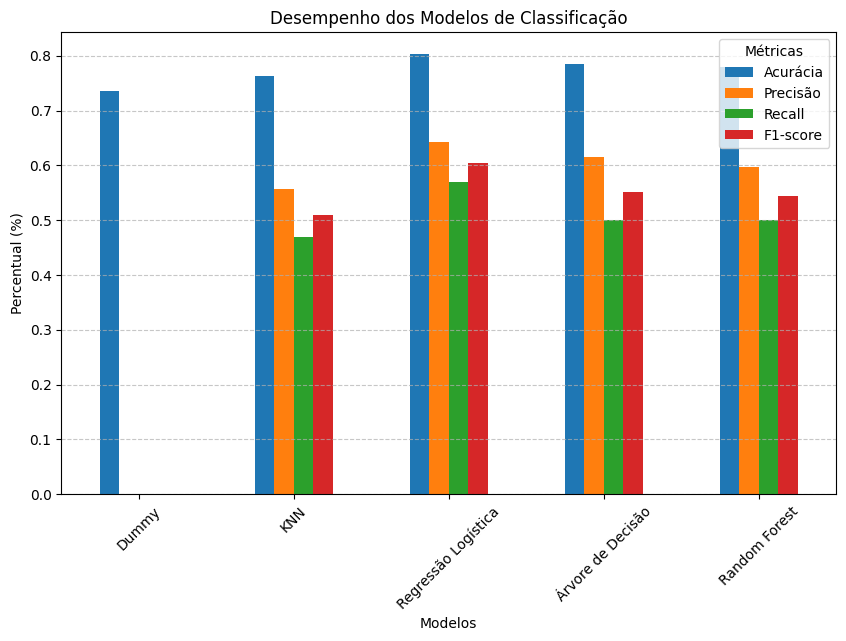

In [34]:
# Plotando gráfico comparativo
dese_geral.plot(kind='bar', figsize=(10,6))
plt.title("Desempenho dos Modelos de Classificação")
plt.ylabel("Percentual (%)")
plt.xlabel("Modelos")
plt.xticks(rotation=45)
plt.legend(title="Métricas")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

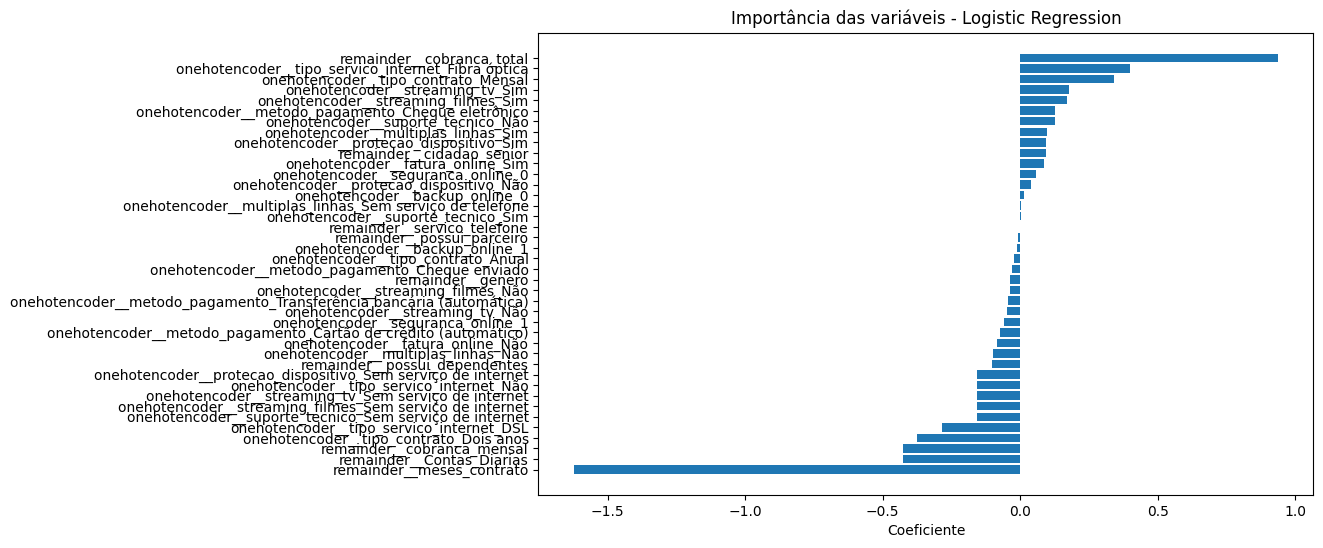

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

coef = pd.DataFrame({
    'Variável': X_train.columns,
    'Importância': model_logreg.coef_[0]
}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(coef['Variável'], coef['Importância'])
plt.title("Importância das variáveis - Logistic Regression")
plt.xlabel("Coeficiente")
plt.gca().invert_yaxis()
plt.show()


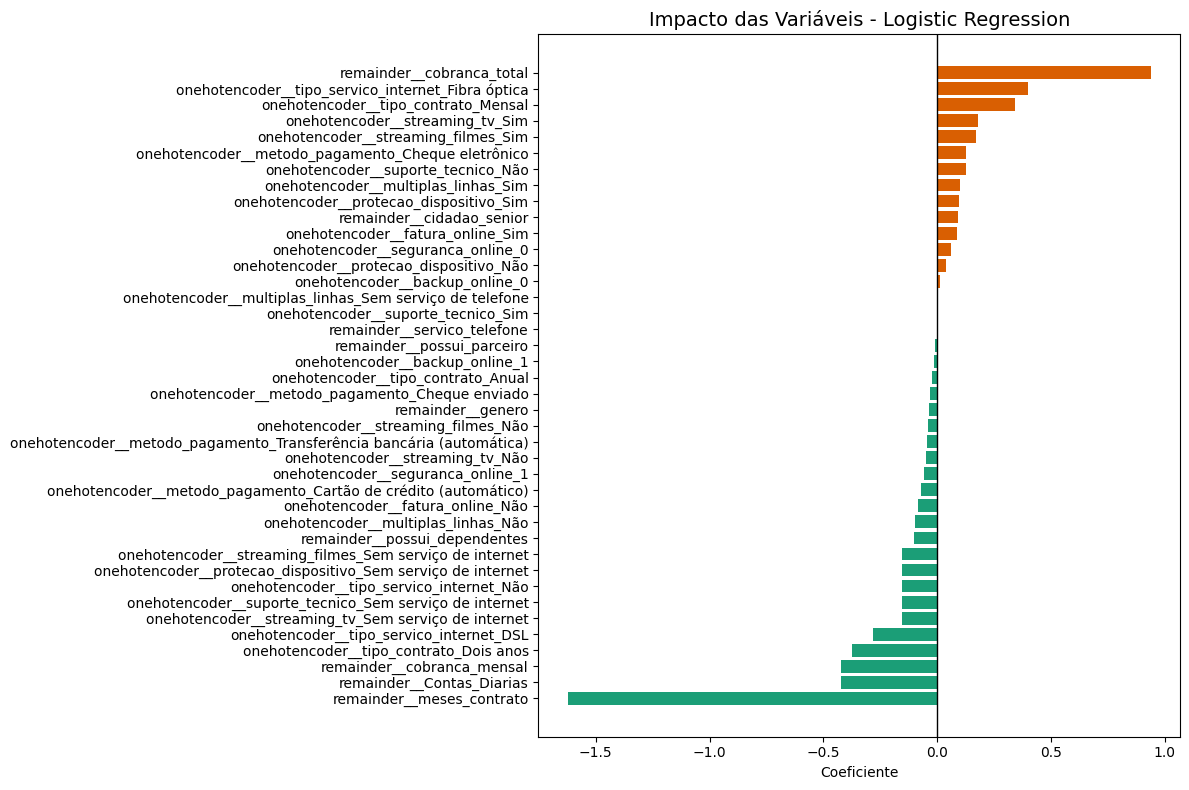

In [36]:
import numpy as np

coef = pd.DataFrame({
    'Variável': X_train.columns,
    'Importância': model_logreg.coef_[0]
}).sort_values(by='Importância')

plt.figure(figsize=(12,8))

cores = ['#d95f02' if x > 0 else '#1b9e77' for x in coef['Importância']]

plt.barh(coef['Variável'], coef['Importância'], color=cores)
plt.axvline(0, color='black', linewidth=1)

plt.title("Impacto das Variáveis - Logistic Regression", fontsize=14)
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()

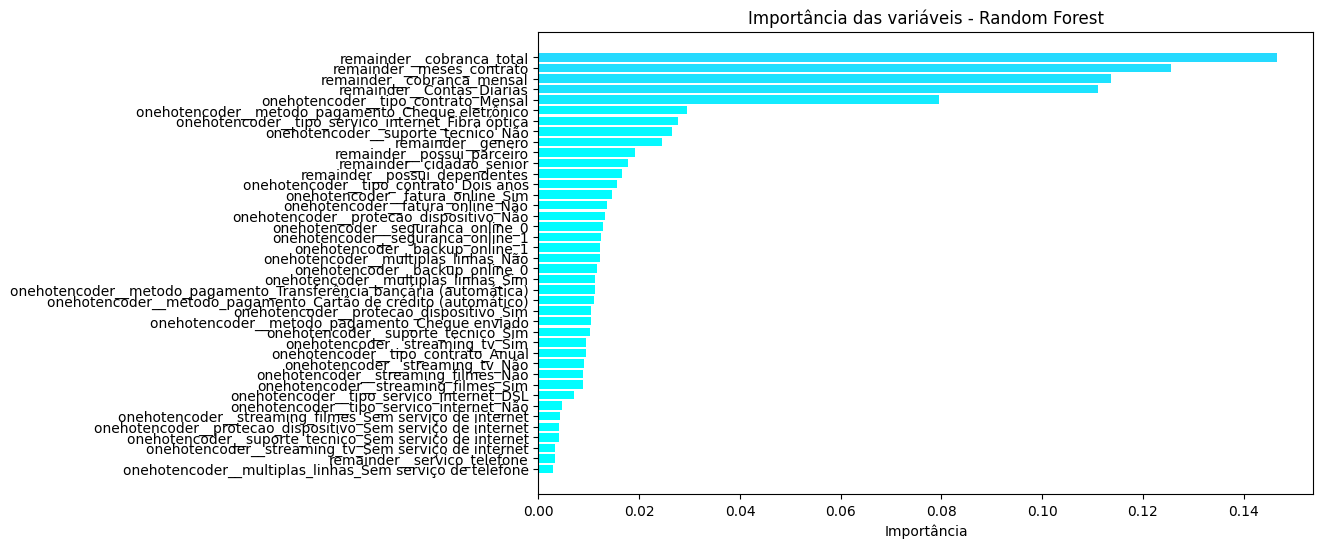

In [37]:
importances = pd.DataFrame({
    'Variável': X_train.columns,
    'Importância': model_rfc.feature_importances_
}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importances['Variável'], importances['Importância'],
         color=plt.cm.cool(importances['Importância']))
plt.title("Importância das variáveis - Random Forest")
plt.xlabel("Importância")
plt.gca().invert_yaxis()
plt.show()

## Análise Estatística e Interpretação dos Resultados

### Exame detalhado das métricas obtidas e discussão dos padrões observados nos dados.


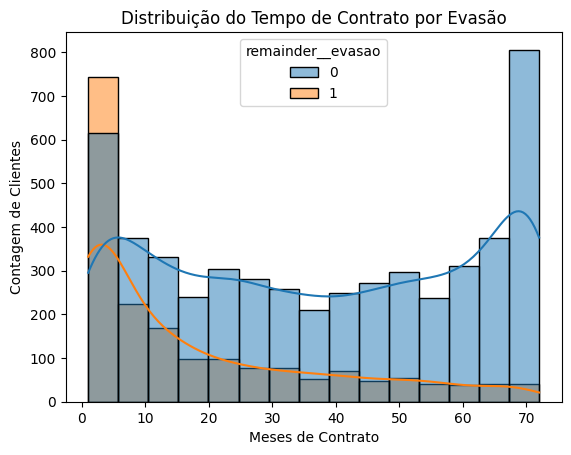

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=dados, x='remainder__meses_contrato', hue='remainder__evasao', kde=True)
plt.title('Distribuição do Tempo de Contrato por Evasão')
plt.xlabel('Meses de Contrato')
plt.ylabel('Contagem de Clientes')
plt.show()

O gráfico apresenta a distribuição do tempo de contrato dos clientes, em meses, associada à ocorrência de evasão. Observa-se que a maior concentração de evasão ocorre nos primeiros meses de contrato, indicando que clientes com pouco tempo de relacionamento com a empresa possuem maior probabilidade de cancelar o serviço. À medida que o tempo de contrato aumenta, a frequência de evasão tende a diminuir, demonstrando que clientes com maior tempo de permanência apresentam maior fidelidade. Dessa forma, o gráfico evidencia que o início do contrato representa um período mais crítico para retenção de clientes, sendo importante a adoção de estratégias voltadas à fidelização nesse estágio inicial.



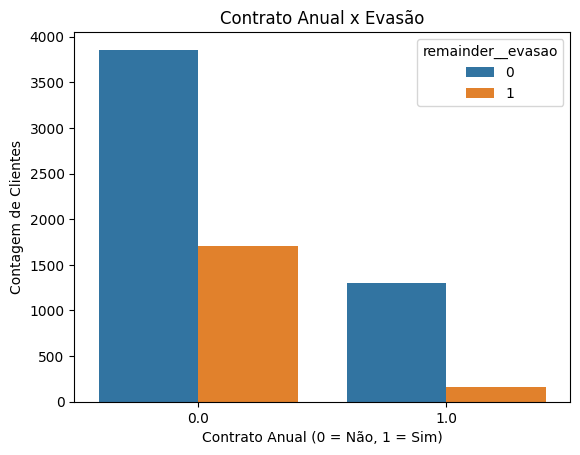

In [39]:
sns.countplot(x='onehotencoder__tipo_contrato_Anual', hue='remainder__evasao', data=dados)
plt.title("Contrato Anual x Evasão")
plt.xlabel("Contrato Anual (0 = Não, 1 = Sim)")
plt.ylabel("Contagem de Clientes")
plt.show()

O gráfico apresenta a relação entre a existência de contrato anual e a evasão de clientes. Observa-se que a maioria dos clientes que não possuem contrato anual (0) apresenta maior quantidade de evasão quando comparados aos clientes que possuem contrato anual (1). Por outro lado, clientes com contrato anual demonstram menor índice de evasão, indicando maior tendência de permanência no serviço. Dessa forma, o tipo de contrato pode ser considerado um fator relevante para a retenção de clientes, sugerindo que contratos de maior duração contribuem para reduzir a evasão.

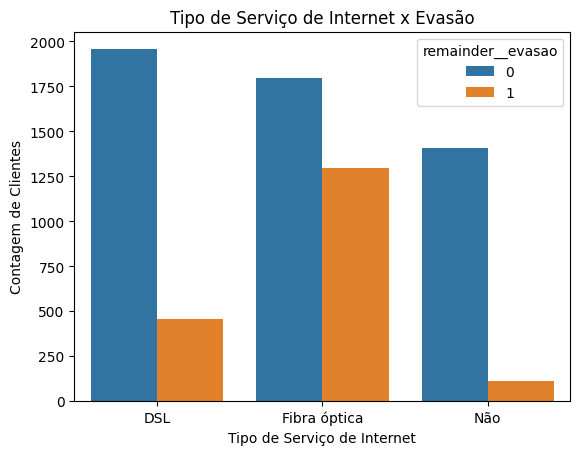

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reconstruct 'tipo_servico_internet' from one-hot encoded columns for plotting
internet_service_cols = [
    'onehotencoder__tipo_servico_internet_DSL',
    'onehotencoder__tipo_servico_internet_Fibra óptica',
    'onehotencoder__tipo_servico_internet_Não'
]

def get_internet_service_type(row):
    if row['onehotencoder__tipo_servico_internet_DSL'] == 1.0:
        return 'DSL'
    elif row['onehotencoder__tipo_servico_internet_Fibra óptica'] == 1.0:
        return 'Fibra óptica'
    elif row['onehotencoder__tipo_servico_internet_Não'] == 1.0:
        return 'Não'
    return 'Outro'

dados['reconstructed_tipo_servico_internet'] = dados.apply(get_internet_service_type, axis=1)

sns.countplot(x='reconstructed_tipo_servico_internet', hue='remainder__evasao', data=dados)
plt.title("Tipo de Serviço de Internet x Evasão")
plt.xlabel("Tipo de Serviço de Internet")
plt.ylabel("Contagem de Clientes")
plt.show()

O gráfico apresenta a relação entre o tipo de serviço de internet e a evasão de clientes. Observa-se que clientes que utilizam fibra óptica apresentam maior quantidade de evasão em comparação aos clientes que utilizam DSL. Já os clientes que não possuem serviço de internet apresentam menor ocorrência de evasão. Esses resultados indicam que o tipo de serviço contratado pode influenciar no comportamento de permanência ou cancelamento dos clientes.


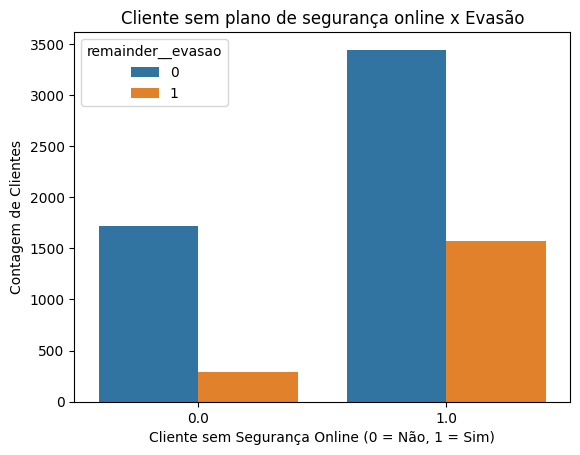

In [41]:
sns.countplot(x='onehotencoder__seguranca_online_0', hue='remainder__evasao', data=dados)
plt.title("Cliente sem plano de segurança online x Evasão")
plt.xlabel("Cliente sem Segurança Online (0 = Não, 1 = Sim)")
plt.ylabel("Contagem de Clientes")
plt.show()

O gráfico mostra a relação entre a ausência de plano de segurança online e a evasão de clientes. Observa-se que clientes que não possuem plano de segurança online apresentam maior quantidade de evasão em comparação aos que possuem esse serviço. Esse resultado sugere que a oferta de serviços adicionais, como segurança online, pode contribuir para aumentar a retenção e reduzir o cancelamento de clientes.



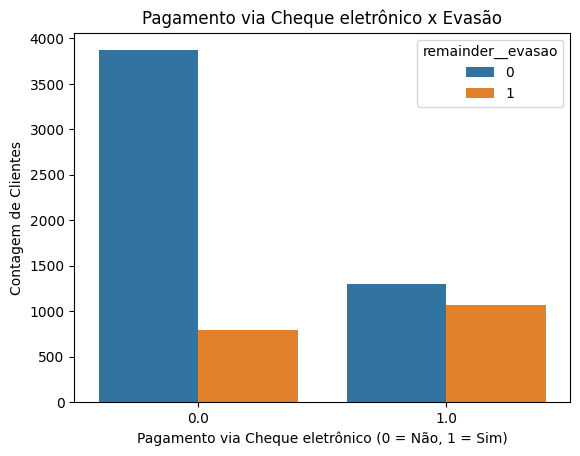

In [42]:
sns.countplot(x='onehotencoder__metodo_pagamento_Cheque eletrônico', hue='remainder__evasao', data=dados)
plt.title("Pagamento via Cheque eletrônico x Evasão")
plt.xlabel("Pagamento via Cheque eletrônico (0 = Não, 1 = Sim)")
plt.ylabel("Contagem de Clientes")
plt.show()

A forma de pagamento demonstra relação com a evasão. Clientes que utilizam cheque eletrônico apresentam proporção mais elevada de cancelamento quando comparados aos demais meios de pagamento.

Embora o número absoluto de clientes seja maior entre os que não utilizam cheque eletrônico, a taxa relativa de evasão é superior entre os que utilizam esse método, indicando possível associação com perfil comportamental ou fricções no processo de cobrança.

Implicações estratégicas

A empresa pode incentivar a migração para métodos como débito automático ou cartão de crédito, além de investigar possíveis dificuldades associadas ao cheque eletrônico.

Essa variável também mostra potencial explicativo relevante dentro de modelos preditivos.

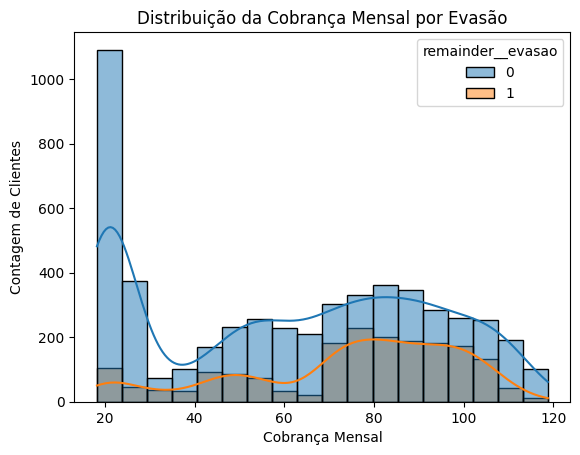

In [43]:
sns.histplot(data=dados, x='remainder__cobranca_mensal', hue='remainder__evasao', kde=True)
plt.title('Distribuição da Cobrança Mensal por Evasão')
plt.xlabel('Cobrança Mensal')
plt.ylabel('Contagem de Clientes')
plt.show()

A análise da cobrança mensal indica um padrão claro entre valor pago e evasão. Clientes que permanecem concentram-se majoritariamente nas faixas de menor valor, especialmente entre 20 e 40. Em contrapartida, a evasão é mais frequente entre clientes com mensalidades intermediárias e elevadas, sobretudo entre 70 e 100.

Esse comportamento sugere que valores mais altos aumentam a probabilidade de cancelamento, possivelmente devido à maior sensibilidade ao preço ou percepção reduzida de custo-benefício.

Implicações estratégicas

A empresa pode direcionar ações de retenção para clientes com maior ticket médio, como ofertas personalizadas, benefícios adicionais ou revisão de planos intermediários.

Além disso, a cobrança mensal se destaca como variável relevante para modelos preditivos de churn.

# Relatório Final – Análise de Evasão de Clientes (Churn)
## Projeto: Telecom X

---

# 1. Introdução

A evasão de clientes, conhecida como churn, é um dos principais desafios enfrentados por empresas do setor de telecomunicações. Quando um cliente cancela seus serviços, a empresa não apenas perde receita, mas também precisa investir recursos adicionais para conquistar novos consumidores.

Nesse contexto, compreender os fatores que influenciam o cancelamento de serviços é essencial para o desenvolvimento de estratégias mais eficientes de retenção.

Este projeto apresenta uma análise exploratória dos dados da empresa Telecom X, com o objetivo de identificar padrões e comportamentos associados à evasão de clientes.

---

# 2. Objetivo do Projeto

O objetivo principal deste projeto é analisar os dados históricos de clientes da Telecom X utilizando ferramentas de análise de dados em Python.

Entre os objetivos específicos estão:

- Identificar fatores associados à evasão de clientes.
- Explorar características demográficas, contratuais e financeiras da base de dados.
- Gerar insights que possam apoiar decisões estratégicas da empresa.
- Demonstrar a aplicação prática de técnicas de análise de dados.

---

# 3. Metodologia

O desenvolvimento do projeto foi dividido em três etapas principais: compreensão dos dados, tratamento da base e análise exploratória.

---

## 3.1 Compreensão dos dados

A base de dados utilizada contém diversas informações sobre os clientes da empresa, incluindo:

- Tempo de permanência na empresa
- Tipo de contrato
- Serviços contratados
- Forma de pagamento
- Valor mensal cobrado
- Indicador de evasão (churn)

Essas variáveis permitem analisar diferentes aspectos do comportamento dos clientes.

---

## 3.2 Limpeza e preparação dos dados

Antes de iniciar a análise, foi necessário realizar um processo de preparação da base de dados para garantir maior qualidade e consistência das informações.

As principais etapas realizadas foram:

- Padronização dos nomes das colunas para o idioma português
- Verificação e tratamento de valores ausentes
- Conversão de variáveis categóricas
- Ajuste dos tipos de dados
- Organização da estrutura da base para facilitar a análise

Essas etapas são fundamentais para garantir maior confiabilidade nos resultados obtidos.

---

## 3.3 Análise exploratória dos dados

Após o tratamento da base, foi realizada uma análise exploratória utilizando estatísticas descritivas e visualizações gráficas.

Os gráficos permitiram:

- Comparar clientes que cancelaram com aqueles que permaneceram na empresa
- Avaliar a relação entre tempo de contrato e evasão
- Analisar o impacto do tipo de contrato
- Identificar padrões relacionados ao valor mensal e à forma de pagamento

Essa etapa foi essencial para identificar tendências e possíveis fatores relacionados ao churn.

---

# 4. Resultados da Análise

## 4.1 Distribuição da evasão

A análise inicial mostrou que uma parcela significativa dos clientes realizou o cancelamento dos serviços, indicando a necessidade de estratégias voltadas à retenção.

---

## 4.2 Tempo de contrato

Clientes com menor tempo de permanência na empresa apresentaram maior probabilidade de cancelamento. Isso indica que os primeiros meses de relacionamento com o cliente são um período crítico para a fidelização.

---

## 4.3 Tipo de contrato

Observou-se que contratos mensais apresentam maior taxa de evasão quando comparados a contratos anuais ou de maior duração. Esse resultado sugere que contratos mais longos contribuem para aumentar a permanência dos clientes.

---

## 4.4 Forma de pagamento

Clientes que utilizam formas de pagamento automáticas, como cartão de crédito ou débito automático, apresentaram menores taxas de cancelamento em comparação com aqueles que utilizam métodos de pagamento manuais.

---

## 4.5 Valor mensal

Foi observado que clientes com valores mensais mais elevados apresentam maior tendência ao cancelamento, o que pode indicar insatisfação em relação ao custo-benefício dos serviços contratados.

---

# 5. Principais Insights

A partir das análises realizadas, alguns pontos importantes foram identificados:

- O risco de evasão é maior nos primeiros meses de contrato.
- Contratos mensais apresentam maior probabilidade de cancelamento.
- Clientes com cobrança mensal mais alta tendem a cancelar com mais frequência.
- Métodos de pagamento automáticos estão associados a menores taxas de evasão.
- Estratégias de fidelização podem contribuir para reduzir o churn.

---

# 6. Recomendações

Com base nos resultados obtidos, algumas ações podem ser consideradas pela empresa:

1. Implementar programas de fidelização voltados principalmente para novos clientes.
2. Incentivar a migração para contratos de maior duração por meio de benefícios ou descontos.
3. Desenvolver planos mais personalizados para clientes com valores mensais elevados.
4. Monitorar clientes com maior risco de evasão para ações preventivas de retenção.
5. Investir na melhoria da experiência do cliente e na qualidade do atendimento.

---

# 7. Conclusão

A análise exploratória realizada neste projeto permitiu identificar fatores relevantes relacionados à evasão de clientes na Telecom X.

Os resultados indicam que variáveis como tempo de permanência, tipo de contrato, valor mensal e forma de pagamento possuem relação direta com o comportamento de cancelamento.

A utilização de análise de dados possibilita transformar informações em conhecimento estratégico, permitindo que a empresa desenvolva ações mais direcionadas para reduzir o churn e melhorar a retenção de clientes.

---

# 8. Próximos Passos

Como continuidade do projeto, algumas possibilidades incluem:

- Aplicação de modelos de Machine Learning para prever a evasão de clientes.
- Avaliação do desempenho dos modelos por meio de métricas como accuracy, precision, recall e F1-score.
- Desenvolvimento de dashboards interativos para acompanhamento dos indicadores.
- Integração da análise com dados de satisfação e histórico de atendimento dos clientes.